# Lecture 2 — Linear Classification and the Perceptron

A from-scratch, executable study notebook. We implement the classifier and perceptron ourselves before using external ML libraries.


## 1. Linear classifier

The score is

$$
f(x)=\theta^T x+\theta_0.
$$

The decision boundary is

$$
\theta^T x+\theta_0=0.
$$

The bias $\theta_0$ lets the boundary move away from the origin.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [4, 4], [5, 3], [3, 5],
    [1, 1], [2, 1], [1, 2],
    [4, 1], [2, 5], [2, 2],
    [1, 5], [1, 3], [3, 4], [5, 4]
])

y = np.array([1, 1, 1, -1, -1, -1, -1, 1, -1, 1, -1, 1, 1])

def score(x, theta, theta0):
    return np.dot(theta, x) + theta0

def predict(x, theta, theta0):
    s = score(x, theta, theta0)
    if s > 0:
        return 1
    if s < 0:
        return -1
    return 0

def agreement(x, label, theta, theta0):
    return label * score(x, theta, theta0)

def training_error(X, y, theta, theta0):
    predictions = np.array([predict(xi, theta, theta0) for xi in X])
    return np.mean(predictions != y)


## 2. Agreement and classification error

For a labelled point $(x_i,y_i)$, define

$$
z_i=y_i(\theta^T x_i+\theta_0).
$$

Positive agreement means the point is correctly classified; negative agreement means it is on the wrong side. This becomes important for hinge loss in Lecture 3.


In [2]:
theta_demo = np.array([2.0, 1.0])
theta0_demo = -4.0

for xi, yi in zip(X[:3], y[:3]):
    print(xi, 'score=', score(xi, theta_demo, theta0_demo),
          'agreement=', agreement(xi, yi, theta_demo, theta0_demo),
          'prediction=', predict(xi, theta_demo, theta0_demo))

print('training error:', training_error(X, y, theta_demo, theta0_demo))


[4 4] score= 8.0 agreement= 8.0 prediction= 1
[5 3] score= 9.0 agreement= 9.0 prediction= 1
[3 5] score= 7.0 agreement= 7.0 prediction= 1
training error: 0.38461538461538464


## 3. XOR failure

XOR is not linearly separable: no single straight line can separate its two classes.


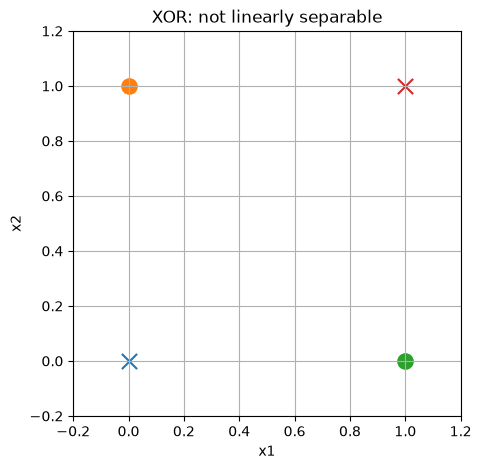

In [3]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([-1, 1, 1, -1])

plt.figure(figsize=(5, 5))
for xi, yi in zip(X_xor, y_xor):
    plt.scatter(xi[0], xi[1], marker='o' if yi == 1 else 'x', s=120)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('XOR: not linearly separable')
plt.grid(True)
plt.show()


## 4. Perceptron learning rule

When an example is misclassified, the perceptron updates

$$
\theta\leftarrow\theta+y_i x_i
$$

and

$$
\theta_0\leftarrow\theta_0+y_i.
$$

The update moves the boundary in a direction that improves the current example's agreement.


In [4]:
def perceptron(X, y, epochs=20):
    theta = np.zeros(X.shape[1], dtype=float)
    theta0 = 0.0
    history = []

    for epoch in range(epochs):
        mistakes = 0

        for xi, yi in zip(X, y):
            if predict(xi, theta, theta0) != yi:
                theta += yi * xi
                theta0 += yi
                mistakes += 1

        error = training_error(X, y, theta, theta0)
        history.append(error)
        print(f'Epoch {epoch + 1}: mistakes={mistakes}, error={error:.3f}, theta={theta}, theta0={theta0:.1f}')

        if mistakes == 0:
            print('Converged.')
            break

    return theta, theta0, history

theta, theta0, history = perceptron(X, y)

print('\nFinal theta:', theta)
print('Final theta0:', theta0)


Epoch 1: mistakes=8, error=0.462, theta=[2. 4.], theta0=-2.0
Epoch 2: mistakes=4, error=0.462, theta=[1. 3.], theta0=-4.0
Epoch 3: mistakes=3, error=0.462, theta=[2. 3.], theta0=-5.0
Epoch 4: mistakes=6, error=0.231, theta=[-1.  5.], theta0=-7.0
Epoch 5: mistakes=2, error=0.462, theta=[1. 7.], theta0=-7.0
Epoch 6: mistakes=4, error=0.308, theta=[1. 5.], theta0=-9.0
Epoch 7: mistakes=1, error=0.077, theta=[0. 3.], theta0=-10.0
Epoch 8: mistakes=8, error=0.231, theta=[0. 7.], theta0=-12.0
Epoch 9: mistakes=3, error=0.231, theta=[1. 6.], theta0=-13.0
Epoch 10: mistakes=1, error=0.077, theta=[0. 4.], theta0=-14.0
Epoch 11: mistakes=3, error=0.000, theta=[2. 4.], theta0=-15.0
Epoch 12: mistakes=0, error=0.000, theta=[2. 4.], theta0=-15.0
Converged.

Final theta: [2. 4.]
Final theta0: -15.0


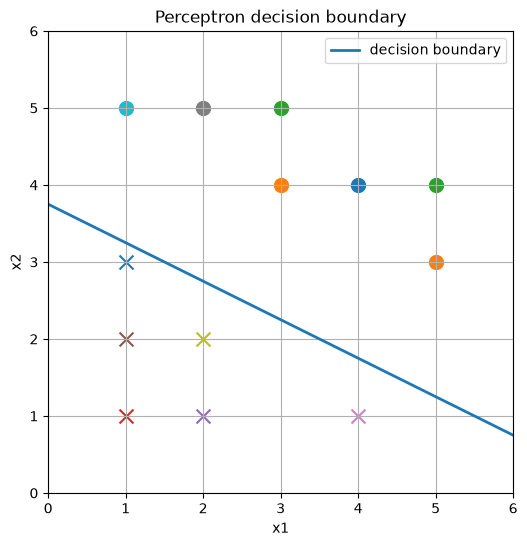

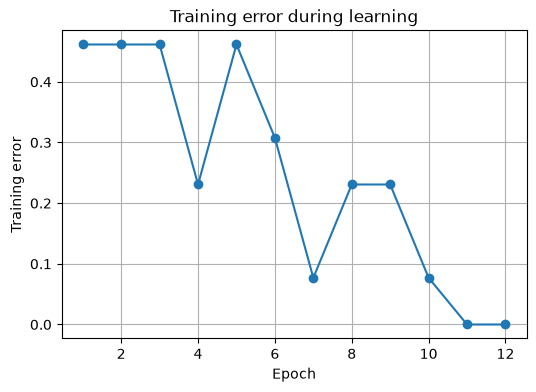

In [5]:
plt.figure(figsize=(6, 6))
for xi, yi in zip(X, y):
    plt.scatter(xi[0], xi[1], marker='o' if yi == 1 else 'x', s=100)

x1 = np.linspace(0, 6, 200)
if abs(theta[1]) > 1e-12:
    x2 = -(theta[0] * x1 + theta0) / theta[1]
    plt.plot(x1, x2, linewidth=2, label='decision boundary')

plt.xlim(0, 6)
plt.ylim(0, 6)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Perceptron decision boundary')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(history) + 1), history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training error')
plt.title('Training error during learning')
plt.grid(True)
plt.show()


## 5. Augmented-vector formulation

The bias can be included as an additional coordinate:

$$
\tilde{x}=\begin{bmatrix}x\\1\end{bmatrix},\qquad\tilde{\theta}=\begin{bmatrix}\theta\\\theta_0\end{bmatrix}.
$$

Then

$$
f(x)=\tilde{\theta}^T\tilde{x}.
$$

This is the same linear classifier expressed as one dot product.


## 6. Connection to Lectures 3 and 4

Lecture 3 builds on this classifier with loss, hinge loss, regularization, and optimization. A typical objective is

$$
J(\theta,\theta_0;\alpha)=L(\theta,\theta_0)+\alpha R(\theta).
$$

Lecture 4 then uses validation and cross-validation to select the hyperparameter $\alpha$.

### Key takeaways

- A linear classifier predicts from $\operatorname{sign}(\theta^T x+\theta_0)$.
- The decision boundary is $\theta^T x+\theta_0=0$.
- The bias moves the boundary.
- Agreement $y_i(\theta^T x_i+\theta_0)$ tells us which side a point lies on.
- The perceptron updates after a mistake.
- XOR cannot be solved by one linear boundary.
